In [3]:
!pip install langchain==0.3.14
!pip install langgraph==0.2.66

In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display, Markdown

In [6]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

Enter Open AI API Key:  ········


In [7]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

In [8]:
from langchain_core.tools import tool

In [17]:
@tool
def get_sum(a:float, b:float) -> float:
    """This function will give the Summation result"""
    return a + b
    

@tool
def get_sub(a:float, b:float) -> float:
    """This function will give the Subtraction result"""
    return a - b

@tool
def get_mul(a:float, b:float) -> float:
    """This function will give the Multiplication result"""
    return a * b

@tool
def get_div(a:float, b:float) -> float:
    """This function will give the Division result"""
    return (a / b) if b != 0 else 0  

# testing out the langchain functions

In [25]:
result = get_div.invoke({"a":4.0,"b":0.0})
display(result)

0

In [26]:
agent_system_prompt='''
You are an intelligent assistant that can handle both general knowledge questions and mathematical operations.

## Core Responsibilities

* For **general queries** (facts, explanations, opinions, summaries, etc.), respond directly using your language understanding.
* For **mathematical operations**, you MUST use the provided tools instead of calculating on your own.

## Available Tools

You have access to the following tools:

* `get_sum(a, b)` → addition
* `get_sub(a, b)` → subtraction
* `get_mul(a, b)` → multiplication
* `get_div(a, b)` → division

## Tool Usage Rules

* ALWAYS use tools when the user asks for:

  * arithmetic calculations
  * numeric problem solving involving +, -, ×, ÷
* DO NOT perform math mentally when a tool is available.
* Extract numerical values carefully from the user query before calling a tool.
* Pass arguments as floats when calling tools.
* For division:

  * If the denominator is 0, call the tool anyway and handle the response gracefully.

## Response Behavior

* If a tool is used:

  * Return the final answer clearly and concisely.
  * Do NOT mention internal tool calls unless explicitly asked.
* If no tool is needed:

  * Provide a natural, helpful response using the LLM.

## Examples

User: What is 5 + 3?
→ Use `get_sum(5, 3)`

User: Multiply 4.5 and 2
→ Use `get_mul(4.5, 2)`

User: Who is the Prime Minister of India?
→ Answer directly without using any tool but LLM

User: What is (10 / 2) + 7?
→ Break into steps using tools as needed

## Important Guidelines

* Be accurate and reliable.
* Prefer tool usage over approximation for math.
* Keep answers concise unless the user asks for explanation.
* Seamlessly switch between reasoning and tool usage.

You are a hybrid reasoning + tool-using agent designed for accuracy and clarity.

'''

In [33]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langchain_core.messages import trim_messages

# Define the state of the graph, which holds the conversation messages
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Initialize the graph builder with the defined state
graph_builder = StateGraph(State)

# List of tools the agent can use (e.g., fetching stock data, searching the web)
tools = [
    get_sum,
    get_sub,
    get_mul,
    get_div
]

# Initialize the LLM (GPT-4) and bind the tools to it
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)

# System message to guide the agent's behavior
SYS_MSG = SystemMessage(content=agent_system_prompt)

# Define the chatbot node, which processes user input and generates responses
def chatbot(state: State):
    # Trim messages to avoid exceeding token limits
    messages = trim_messages(
        state["messages"],
        max_tokens=127000,
        strategy="last", # keep last 127K tokens in messages
        token_counter=ChatOpenAI(model="gpt-4o"),
        include_system=True, # keep system message always
        allow_partial=True, # trim messages to partial content if needed
    )
    # Invoke the LLM with the system message and trimmed conversation history
    return {"messages": [llm_with_tools.invoke([SYS_MSG] + messages)]}

# Add the chatbot node to the graph
graph_builder.add_node("chatbot", chatbot)

# Add a node for executing tools (e.g., fetching data, searching the web)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# Add conditional edges: the chatbot decides whether to use tools or end the conversation
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    ['tools', END]
)

# After using a tool, return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")

# Set the chatbot as the entry point of the graph
graph_builder.set_entry_point("chatbot")

# Compile the graph into a runnable agent
tool_based_analyst_agent = graph_builder.compile()

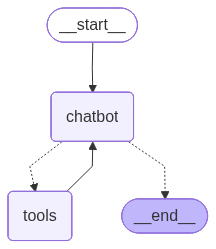

In [37]:
from IPython.display import display, Image

Image(tool_based_analyst_agent.get_graph().draw_mermaid_png())

In [35]:
from IPython.display import display, Markdown

response = llm.invoke('Who is the prime minister of India?')
display(Markdown(response.content))

As of my last update, the Prime Minister of India is Narendra Modi. He has been in office since May 26, 2014. Please verify with a current source, as this information may have changed after October 2023.

In [36]:
response = llm.invoke('what is 2+4')
display(Markdown(response.content))

2 + 4 equals 6.

In [31]:
def call_agent(agent, prompt, user_config={"configurable": {"thread_id": "any"}}):
    events = agent.stream(
        {"messages": [{"role": "user", "content": prompt}]},
        user_config,
        stream_mode="values",
    )

    for event in events:
        event["messages"][-1].pretty_print()

    print()
    print('Final Response:\n')
    display(Markdown(event["messages"][-1].content))

In [38]:
query = 'Who is the prime minister of India?'
call_agent(tool_based_analyst_agent, query)

================================ Human Message =================================

Who is the prime minister of India?
================================== Ai Message ==================================

The Prime Minister of India is Narendra Modi.

Final Response:



The Prime Minister of India is Narendra Modi.

In [40]:
query = 'What is 2+4'
call_agent(tool_based_analyst_agent, query)

================================ Human Message =================================

What is 2+4
================================== Ai Message ==================================
Tool Calls:
  get_sum (call_Ho4UisoUvqw1j260EA2OUeb2)
 Call ID: call_Ho4UisoUvqw1j260EA2OUeb2
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: get_sum

6.0
================================== Ai Message ==================================

The result of 2 + 4 is 6.

Final Response:



The result of 2 + 4 is 6.

In [41]:
query = 'What is 2/4'
call_agent(tool_based_analyst_agent, query)

================================ Human Message =================================

What is 2/4
================================== Ai Message ==================================
Tool Calls:
  get_div (call_oqFxjn0KGXGSikatxecjInpV)
 Call ID: call_oqFxjn0KGXGSikatxecjInpV
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: get_div

0.5
================================== Ai Message ==================================

The result of \( \frac{2}{4} \) is 0.5.

Final Response:



The result of \( \frac{2}{4} \) is 0.5.

In [42]:
query = 'What is (2+4)/3'
call_agent(tool_based_analyst_agent, query)

================================ Human Message =================================

What is (2+4)/3
================================== Ai Message ==================================
Tool Calls:
  get_sum (call_6leeSdCpIqXVxPaC3dqCRyhI)
 Call ID: call_6leeSdCpIqXVxPaC3dqCRyhI
  Args:
    a: 2
    b: 4
  get_div (call_UsPZvVJ5Dj0hs5XWGTglVTPX)
 Call ID: call_UsPZvVJ5Dj0hs5XWGTglVTPX
  Args:
    a: 6
    b: 3
================================= Tool Message =================================
Name: get_div

2.0
================================== Ai Message ==================================

The result of \((2 + 4) / 3\) is 2.0.

Final Response:



The result of \((2 + 4) / 3\) is 2.0.